# Bayesian calibration: $\alpha$ + $^{40,44,48}$Ca at 29 MeV

This notebook follows [quickstart](./quickstart.ipynb), which fit a single optical potential to $\alpha$ + $^{44}$Ca.  

Here, we will go further, performing a full Bayesian calibration of the same optical model potential to $\alpha$ + $^{40,44,48}$Ca at 29 MeV. Again, we use the [Oeschler, 1972](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.28.694) ([EXFOR F0567](https://www-nds.iaea.org/exfor/servlet/X4sSearch5?EntryID=150567)), a very interesting paper which notices that the large-angle behavior of the elastic scattering cross section for $\alpha$-particles strongly depends on the shell structure of the target. Targets which can form a stable, closed shell compound nucleus by absorbing an $\alpha$ show cross sections we would typically attribute to an absorptive optical potential - strongly decreasing at large angles. On the other hand, closed shell targets showed enhanced elastic cross sections at large angles, consistent with very little absorption. 

We will investigate this trend by inferring posterior distributions of the optical model parameters, given the experimental data from Oeschler, 1972. Based on this, we will be able to make uncertainty quantified statements about this physics trend. Along the way, we will learn the basics of Bayesian calibration of optical potentials using `jitr`.

Oeschler, 1972 reports no experimental uncertainties, so we will have to infer the errors along with the potential. For this, we will assume a Gaussian model-data defect, and use a simple, two-term covariance which makes few assumptions. 


As in the quickstart, we will first set up the reaction, solver and potential. Then, we will
- write down our two-parameter error model and put priors on everything
- sample the posterior for each isotope using *nested sampling*
- compare the potentials between isotopes
- check the posterior predictive distribution against the data using *credible interval bands* and *empirical coverage*

In [1]:
# keep every process single-threaded: we will parallelize over likelihood
# evaluations with multiprocessing below, and nested BLAS/numba threads would
# oversubscribe the CPU. Must be set before numpy/jitr are imported.
import os

for var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMBA_NUM_THREADS"):
    os.environ.setdefault(var, "1")

# JITR_QUICK=1 runs a cut-down version of the notebook (fewer data points and live points) for CI
QUICK = os.environ.get("JITR_QUICK", "0") == "1"

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats

## Set up the reaction

In [2]:
from jitr.reactions.reaction import Reaction

targets = {"Ca40": (40, 20), "Ca44": (44, 20), "Ca48": (48, 20)}
alpha = (4, 2)
reactions = {
    key: Reaction(target=target, projectile=alpha, process="El")
    for key, target in targets.items()
}

# calculate kinematics for a given lab energy
energy_lab = 29
kinematics = {key: reaction.kinematics(energy_lab) for key, reaction in reactions.items()}

## Read in data

The data file contains the ratio of the elastic differential cross section to Rutherford for the three targets, digitized from Fig. 1 of Oeschler *et al.*.

In [3]:
df = pd.read_csv("./alpha_ca_ratio_ruth.csv")
if QUICK:
    df = df.iloc[::4]
data = {
    key: {"x": group["angle_cm_deg"].to_numpy(), "y": group["ratio_to_rutherford"].to_numpy()}
    for key, group in df.groupby("target")
}
colors = {"Ca40": "#109618", "Ca44": "#3366CC", "Ca48": "#FF9900"}
isotope_label = {key: rf"$^{{{A}}}$Ca" for key, (A, Z) in targets.items()}

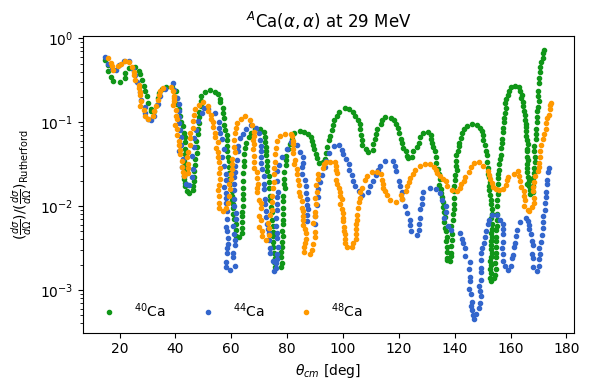

In [4]:
plt.figure(figsize=(6, 4))
for key, dataset in data.items():
    plt.plot(dataset["x"], dataset["y"], linestyle="none", marker=".", label=isotope_label[key], color=colors[key])

plt.yscale("log")
plt.legend(ncol=3, framealpha=0)
plt.xlabel(r"$\theta_{cm}$ [deg]")
plt.ylabel(r"$(\frac{d\sigma}{d\Omega}) / (\frac{d\sigma}{d\Omega})_\text{Rutherford}$")
plt.title(r"$^{A}$Ca($\alpha,\alpha$) at 29 MeV")
plt.tight_layout()
plt.show()

Notice the experimental evidence for trend highlighted in the paper - closed shell $^{48}$Ca and expecially $^{40}$Ca have very enhanced elastic cross sections at backwards angles, relative to the mid-shell $^{44}$Ca. 

## Compile the solver

Each target gets its own solver, evaluated on the angles at which that target was measured. Building a solver compiles code, so we do it once here and keep the objects around.

In [5]:
from jitr.rmatrix import Solver as SolverKernel
from jitr.utils import utils
from jitr.xs import elastic

lmax = 60


def build_solver(key, angles_deg):
    A, Z = targets[key]
    interaction_range_fm = 1.2 * (A ** (1 / 3) + 4 ** (1 / 3)) + 2
    channel_radius_dimensionless = utils.suggested_dimensionless_channel_radius(
        interaction_range_fm, kinematics[key].k
    )
    channel_radius = channel_radius_dimensionless / kinematics[key].k
    N = utils.suggested_basis_size(channel_radius_dimensionless, zeros_per_node=8)
    print(f"Compiling solver for {reactions[key]} at {energy_lab} MeV: "
          f"channel radius {channel_radius:1.2f} fm, {N} nodes, {lmax} partial waves")
    return elastic.DifferentialWorkspace.build_from_system(
        reaction=reactions[key],
        kinematics=kinematics[key],
        channel_radius_fm=channel_radius,
        solver=SolverKernel(N),
        lmax=lmax,
        angles=np.deg2rad(angles_deg),
    )


solvers = {key: build_solver(key, data[key]["x"]) for key in targets}

Compiling solver for 40-Ca(alpha,el) at 29 MeV: channel radius 10.94 fm, 64 nodes, 60 partial waves
Compiling solver for 44-Ca(alpha,el) at 29 MeV: channel radius 11.05 fm, 64 nodes, 60 partial waves
Compiling solver for 48-Ca(alpha,el) at 29 MeV: channel radius 11.15 fm, 64 nodes, 60 partial waves


In [6]:
# jit warmup - do this before forking worker processes later so they inherit compiled code
for solver in solvers.values():
    _ = solver.xs(central_potential=np.zeros_like(solver.radial_grid()))

## Define the interaction model and parameters

A real volume Woods-Saxon, an imaginary volume term and an imaginary surface term, plus the Coulomb potential of a uniformly charged sphere. The seven free parameters are the depths $V$, $W_v$, $W_s$ and the geometry $r_v, a_v, r_w, a_w$ (radii in units of $A^{1/3}$ fm; the surface term shares the imaginary geometry).

In [7]:
from jitr.optical_potentials.potential_forms import (
    coulomb_charged_sphere as coulomb,
    woods_saxon_safe as ws,
    woods_saxon_prime_safe as wsp,
)


def U_central(r, Vv, Wv, Ws, Rv, av, Rw, aw):
    return -Vv * ws(r, Rv, av) - 1j * Wv * ws(r, Rw, aw) - 1j * Ws * (-4 * aw) * wsp(r, Rw, aw)


def calculate_xs_ratio(theta, key):
    """Ratio to Rutherford on the data angles of `key` for optical model parameters `theta`."""
    solver = solvers[key]
    reaction = reactions[key]
    # each solver has its own radial quadrature grid (it depends on the channel radius)
    rgrid = solver.radial_grid()
    Vv, Wv, Ws, rv, av, rw, aw = theta
    A_factor = reaction.target.A ** (1 / 3)
    Zz = reaction.target.Z * reaction.projectile.Z
    xs = solver.xs(
        central_potential=U_central(rgrid, Vv, Wv, Ws, rv * A_factor, av, rw * A_factor, aw),
        coulomb_potential=coulomb(rgrid, Zz, 1.3 * A_factor),
    )
    return xs.dsdo / solver.rutherford


names = ["Vv", "Wv", "Ws", "rv", "av", "rw", "aw"]
labels = [r"$V$", r"$W_v$", r"$W_s$", r"$r_v$", r"$a_v$", r"$r_w$", r"$a_w$"]
n_omp = len(names)

## The error model

We do not know the experimental uncertainties, and the optical model is not a perfect description of the reaction, so we need a model for the residuals $y_i - f(\theta_i;\alpha)$, where $f(\theta;\alpha) \equiv f_i$ is the model prediction at angle $\theta_i^{cm}$, for OMP parameters $\alpha$. 

We take the residuals to be Gaussian with covariance

$$
\Sigma_{ij} = s^2 \delta_{ij} + b^2 f(\theta_i;\alpha) f(\theta_j;\alpha) ,
$$

with two unknown scales: $s$ is an **absolute noise floor**, independent from point to point, which matters where the ratio to Rutherford is small; $b$ is a **relative error common to all points** - it acts like an uncertainty in the overall normalization, or more generally a coherent misfit of the model.

The data span four decades and the natural errors are multiplicative, so we evaluate the likelihood in log space, $r_i = \log y_i - \log f_i$. Take the two error sources to be independent lognormal factors, so we have $y_i = f_i\, A_i\, B$ with:
- $\mathbb{E} \left[ A_i \right]  = \mathbb{E} \left[ B \right] = 1$,
- $\mathrm{Var}[B] = b^2$
-  $\mathrm{Var}[A_i] = \frac{s^2}{f_i^2 (1+b^2) }$,

which reproduces $\Sigma$ in linear space exactly: 

$$
\mathrm{Var}[y_i] = f_i^2[(1 + \mathrm{Var}A_i)(1 + \mathrm{Var}B) - 1] = s^2 + b^2 f_i^2
$$

$$
\mathrm{Cov}[y_i, y_j] = b^2 f_i f_j,
$$

and gives in log space

$$
\Sigma^{\log}_{ij} = \delta_{ij} \log\!\left(1 + \frac{s^2}{f_i^2 (1 + b^2)}\right) + \log\!\left(1 + b^2\right) ,
$$

The log-likelihood is therefore 

$$
-\frac{1}{2}\left(r^T (\Sigma^{\log})^{-1} r + \log\det \Sigma^{\log} + N\log 2\pi\right) - \sum_i \log y_i.
$$

The last term is the Jacobian that makes this a density for the data $y$ rather than for $\log y$. It is a constant (not $\alpha$, $b$, or $s$ dependent) here, but keeping it makes the evidence comparable to a linear-space likelihood.

In [8]:
ERR_NAMES = ["log_s", "log_b"]
ERR_LABELS = [r"$s$", r"$b$"]
n_err = len(ERR_NAMES)
ndim = n_omp + n_err
all_labels = labels + ERR_LABELS


def unpack(theta):
    return theta[:n_omp], np.exp(theta[n_omp:])  # potential parameters, (s, b)


def log_likelihood(theta, key):
    omp, (s, b) = unpack(theta)
    y = data[key]["y"]
    if np.any(omp[3:] <= 0):  # radii and diffusenesses must be positive
        return -1e300
    u = calculate_xs_ratio(omp, key)
    if np.any(u <= 0) or not np.all(np.isfinite(u)):
        return -1e300
    r = np.log(y) - np.log(u)
    beta = np.log1p(b**2)
    d = np.log1p((s / u) ** 2 / (1 + b**2))
    w = r / d
    c = 1.0 + beta * np.sum(1.0 / d)
    quad = r @ w - beta * np.sum(w) ** 2 / c
    logdet = np.sum(np.log(d)) + np.log(c)
    jacobian = -np.sum(np.log(y))  # density for y, not log y
    return -0.5 * (quad + logdet + r.size * np.log(2 * np.pi)) + jacobian


def predictive_draw(s, b, u, rng):
    """One synthetic data set drawn from the error model around the model prediction u."""
    # independent floor + one shared relative shift, in log space
    eps = np.sqrt(np.log1p((s / u) ** 2 / (1 + b**2))) * rng.normal(size=u.shape) + np.sqrt(np.log1p(b**2)) * rng.normal()
    return u * np.exp(eps)

## Prior

We take, for each isotope, a Gaussian prior wide enough ($\sim$20 MeV in $V$, 0.2 fm in the diffusenesses, 0.3 $A^{1/3}$ fm $\approx$ 1 fm in the radii) to let the data move the parameters freely and to admit the continuous $V$-$r_v$ ambiguity, while resolving any multi-modality in $V$. We center the prior on physically resonable numbers, which encode our physical observation that $^{44}$Ca is more absorbing. We will truncate the prior at 0, but we wont force an upper bound.

The error scales are unknown by orders of magnitude, so they get wide log-uniform priors centered at 5% and are sampled as logarithms.

In [9]:
prior_center = {
    "Ca40": np.array([160, 15, 10, 1.4, 0.5, 1.4, 0.3]),
    "Ca44": np.array([150, 20, 20, 1.4, 0.5, 1.4, 0.3]),
    "Ca48": np.array([200, 15, 10, 1.4, 0.5, 1.4, 0.3]),
}
prior_std = np.array([20, 10, 10, 0.3, 0.2, 0.3, 0.2])

omp_prior = {
    key: stats.truncnorm(a=0, b=np.inf, loc=center, scale=prior_std)
    for key, center in prior_center.items()
}

err_prior = [
    stats.loguniform(5e-2, 1.0),  # s: absolute floor on the ratio to Rutherford
    stats.loguniform(5e-2, 2.0),  # b: relative, fully correlated error
]


def prior_transform(u, key):
    omp = omp_prior[key].ppf(u[:n_omp])
    err = [np.log(p.ppf(ui)) for p, ui in zip(err_prior, u[n_omp:])]
    return np.concatenate([omp, err])

## Sampling the posterior

There are many third party libraries that can sample a posterior distribution given a likeihood and prior. We will use a neat one: [dynesty](https://dynesty.readthedocs.io/en/stable/quickstart.html), which does something called [nested sampling](https://en.wikipedia.org/wiki/Nested_sampling_algorithm), which has the advantages that it
- naturally handles multimodal posteriors
- computes the Bayesian evidence along with the prior for free

Each likelihood evaluation is an R-matrix solve, a few milliseconds, and independent of the others, so we hand `dynesty` a `multiprocessing` pool (`fork` so that the workers inherit the compiled solvers; Linux/macOS only). Expect a few minutes per isotope with 4 workers.


In [10]:
import multiprocessing
from functools import partial

import dynesty

n_workers = min(4, os.cpu_count())
nlive = 50 if QUICK else 250
dlogz = 5.0 if QUICK else 1.0
print(f"Using {n_workers} worker processes, nlive={nlive}, dlogz={dlogz}")

Using 4 worker processes, nlive=250, dlogz=1.0


In [11]:
%%time
results = {}
with multiprocessing.get_context("fork").Pool(n_workers) as pool:
    for key in targets:
        sampler = dynesty.NestedSampler(
            partial(log_likelihood, key=key),
            partial(prior_transform, key=key),
            ndim,
            nlive=nlive,
            sample="rwalk",
            pool=pool,
            queue_size=n_workers,
            rstate=np.random.default_rng(0),
        )
        sampler.run_nested(dlogz=dlogz, print_progress=False)
        results[key] = sampler.results
        print(f"{key}: log Z = {results[key].logz[-1]:.2f} +/- {results[key].logzerr[-1]:.2f}, "
              f"{int(np.sum(results[key].ncall))} calls, efficiency {results[key].eff:.1f} %")


Ca40: log Z = 820.81 +/- 0.79, 235515 calls, efficiency 3.8 %
Ca44: log Z = 880.33 +/- 0.53, 136696 calls, efficiency 4.0 %
Ca48: log Z = 838.85 +/- 0.60, 161035 calls, efficiency 3.9 %
CPU times: user 19.2 s, sys: 1.44 s, total: 20.6 s
Wall time: 35min 1s


Equally weighted posterior samples, and for a subset of them the model curve and a few synthetic data sets drawn from the error model - the posterior predictive distribution.

In [12]:
%%time
n_draws = 100 if QUICK else 300
n_noise_replicates = 4
rng = np.random.default_rng(42)

posterior_samples = {}  # equally weighted samples (all)
posterior_draws = {}  # subset used for predictions
posterior_model = {}  # model curves for the subset
posterior_predictive = {}  # model + error model, for the data
for key, res in results.items():
    samples = res.samples_equal(rstate=rng)
    posterior_samples[key] = samples
    draws = samples[rng.choice(len(samples), size=min(n_draws, len(samples)), replace=False)]
    posterior_draws[key] = draws
    posterior_model[key] = np.array([calculate_xs_ratio(unpack(s)[0], key) for s in draws])
    posterior_predictive[key] = np.array([
        predictive_draw(*unpack(s)[1], m, rng)
        for _ in range(n_noise_replicates) for s, m in zip(draws, posterior_model[key])
    ])


CPU times: user 10.8 s, sys: 3.19 ms, total: 10.8 s
Wall time: 10.8 s


## Posterior distributions

First the seven potential parameters for the three isotopes on one corner plot. Within each isotope the familiar $V$-$r_v$ anticorrelation is visible. Look at the $V$ column: for $^{40}$Ca the data have pulled $V$ some 25 MeV (more than one prior width) away from the prior centre, and $r_v$ with it along the ambiguity - the semi-local prior is doing what it should, selecting a family without dictating where in it the posterior sits. With a prior this wide a neighbouring family can leak in and produce a bimodal posterior (it does for $^{40}$Ca if you tighten `dlogz` or change the seed); nested sampling handles that without help, but it is a reminder that the family choice is ours, not the data's.

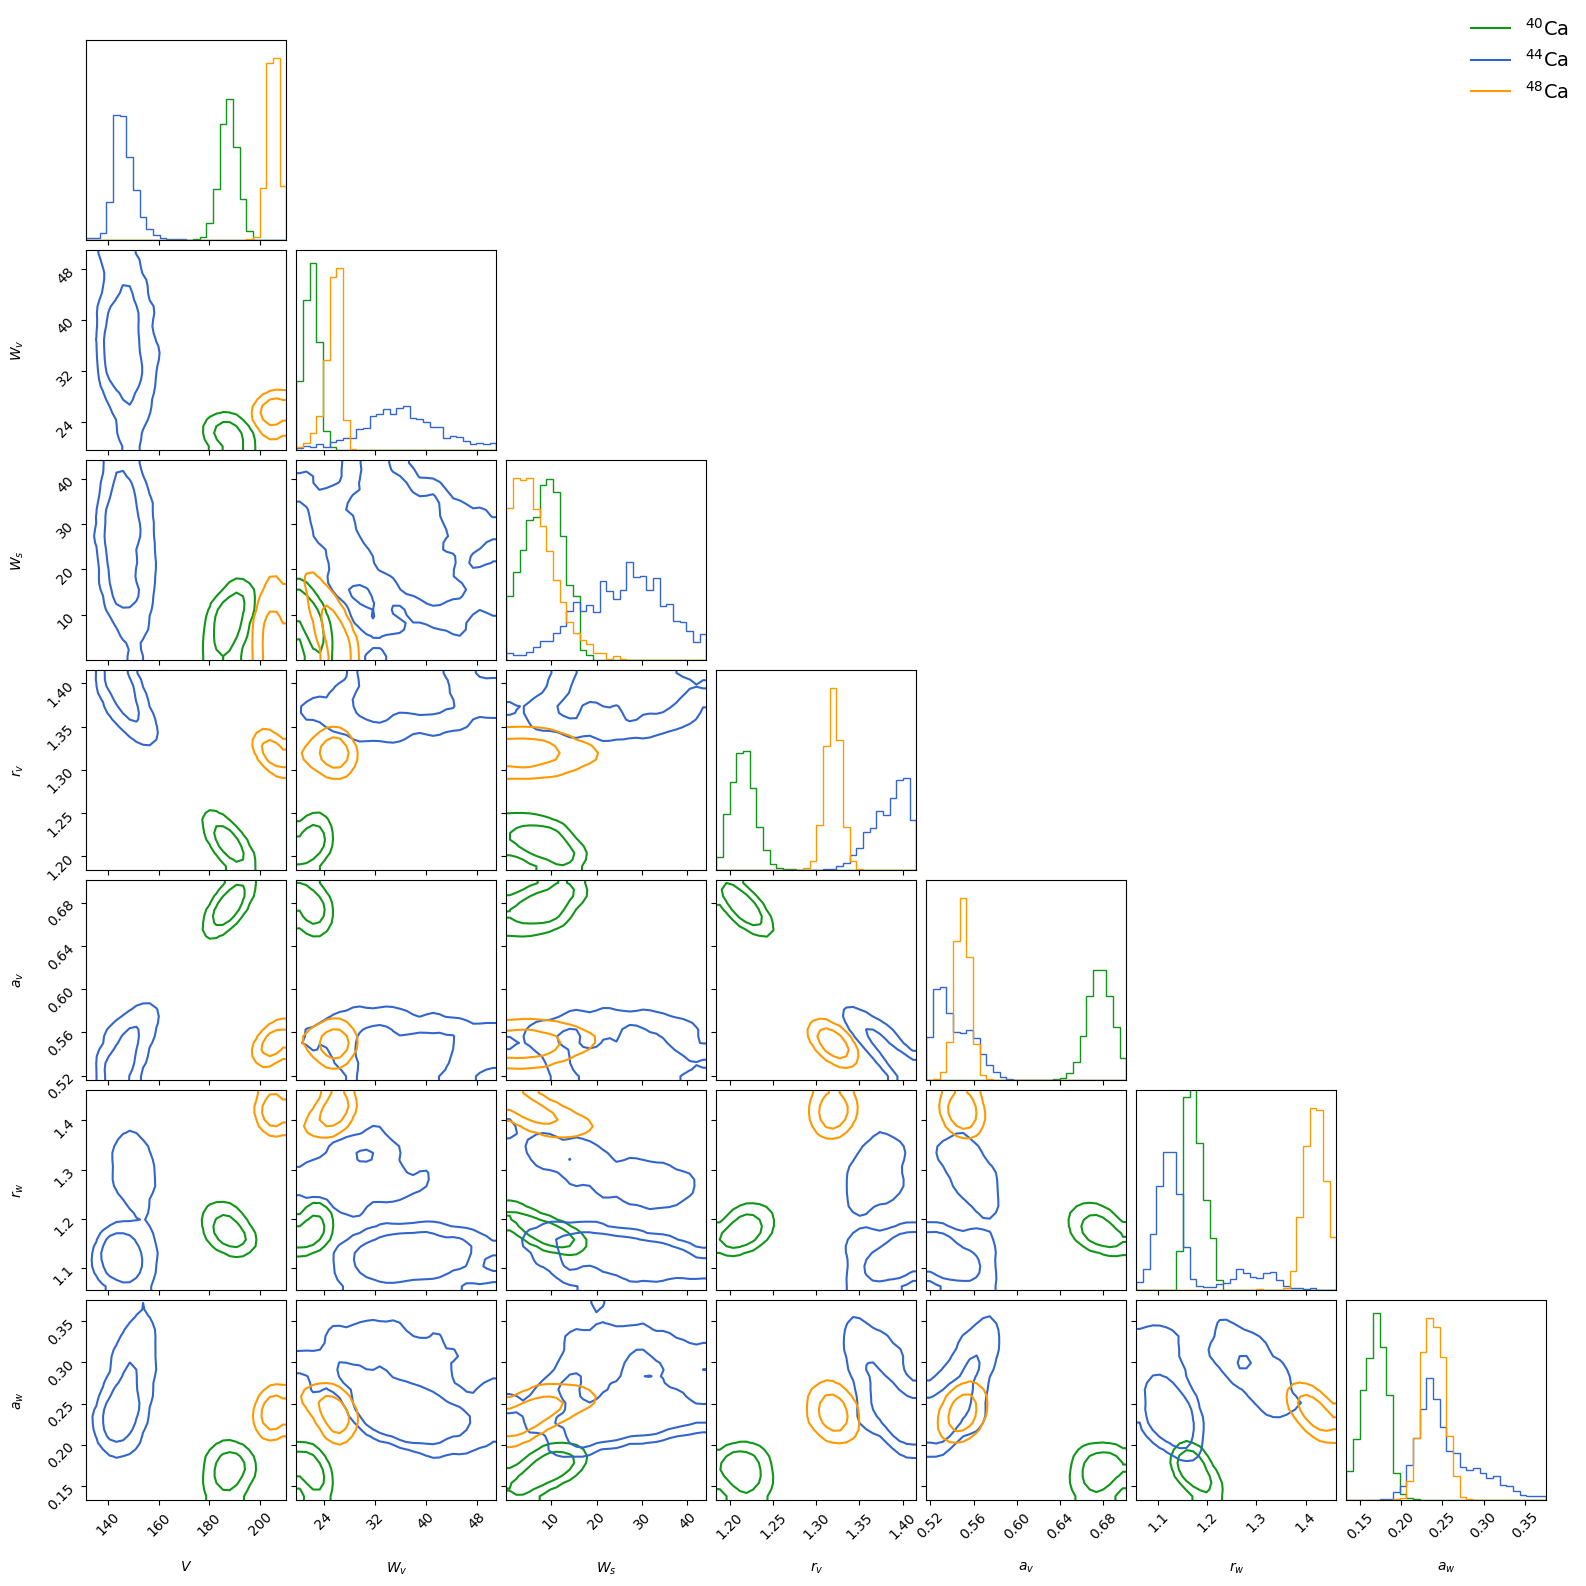

In [13]:
import corner
from matplotlib.lines import Line2D


def corner_overlay(samples, labels, keys, ranges=None, **kwargs):
    """Overlay corner plots for several isotopes with a common range."""
    if ranges is None:
        allsamples = np.vstack([samples[key] for key in keys])
        ranges = list(zip(np.percentile(allsamples, 0.5, axis=0), np.percentile(allsamples, 99.5, axis=0)))
    fig = None
    for key in keys:
        fig = corner.corner(
            samples[key],
            labels=labels,
            color=colors[key],
            fig=fig,
            range=ranges,
            bins=30,
            smooth=1.0,
            plot_datapoints=False,
            plot_density=False,
            levels=(0.68, 0.95),
            hist_kwargs={"density": True},
            **kwargs,
        )
    fig.legend(
        handles=[Line2D([], [], color=colors[key], label=isotope_label[key]) for key in keys],
        loc="upper right", fontsize=14, framealpha=0,
    )
    return fig


omp_samples = {key: posterior_samples[key][:, :n_omp] for key in targets}
fig = corner_overlay(omp_samples, labels, list(targets))
plt.show()

Then the two error scales, transformed back from their logarithms.

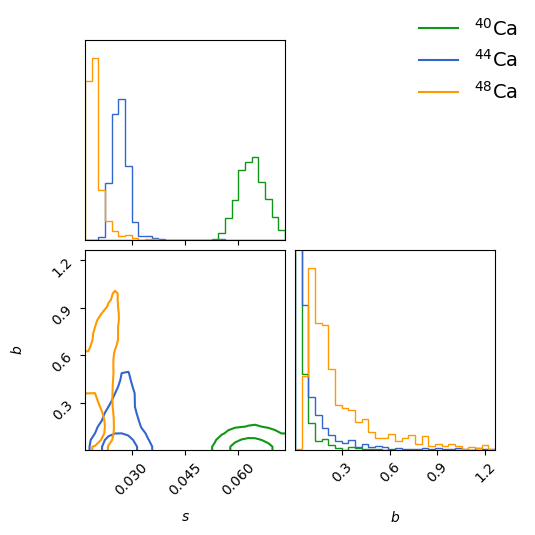

In [14]:
err_samples = {key: np.exp(posterior_samples[key][:, n_omp:]) for key in targets}
fig = corner_overlay(err_samples, ERR_LABELS, list(targets))
plt.show()


A table of medians and central 68% intervals for everything. Because of the $V$-$r_v$ ambiguity the individual geometry parameters are not the best thing to compare between isotopes; the real volume integral per interacting nucleon pair,

$$
\frac{J_V}{4A} = \frac{4\pi}{4A}\int_0^\infty V\, f_{WS}(r; R_v, a_v)\, r^2\, dr ,
$$

is nearly invariant along the ambiguity and is the quantity usually quoted for $\alpha$ potentials, so we add it.


In [15]:
def volume_integral_per_nucleon(samples, key):
    """J_V / (4 A) [MeV fm^3] for each posterior sample."""
    A = targets[key][0]
    r = np.linspace(0, 20, 2000)
    out = np.empty(len(samples))
    for i, (Vv, _, _, rv, av, _, _) in enumerate(samples[:, :n_omp]):
        out[i] = 4 * np.pi * np.trapezoid(Vv * ws(r, rv * A ** (1 / 3), av) * r**2, r) / (4 * A)
    return out


jv_samples = {key: volume_integral_per_nucleon(posterior_samples[key], key) for key in targets}


def summarize(samples):
    q = np.percentile(samples, [16, 50, 84], axis=0)
    return [f"{m:.3g} [{lo:.3g}, {hi:.3g}]" for lo, m, hi in q.T]


pd.DataFrame(
    {
        isotope_label[key]: summarize(np.column_stack([posterior_samples[key][:, :n_omp], err_samples[key], jv_samples[key]]))
        for key in targets
    },
    index=names + ["s", "b", "J_V/4A [MeV fm^3]"],
)


,$^{40}$Ca,$^{44}$Ca,$^{48}$Ca
Vv,"188 [184, 191]","146 [143, 150]","205 [203, 208]"
Wv,"22.1 [20.9, 23.2]","36.1 [30.6, 42.2]","25.7 [24.3, 26.5]"
Ws,"8.62 [3.87, 12.4]","26.8 [15.6, 35.7]","5.77 [2.02, 11.2]"
rv,"1.22 [1.2, 1.23]","1.39 [1.36, 1.41]","1.32 [1.31, 1.33]"
av,"0.677 [0.666, 0.688]","0.538 [0.525, 0.56]","0.55 [0.543, 0.557]"
rw,"1.17 [1.16, 1.19]","1.13 [1.1, 1.25]","1.42 [1.4, 1.44]"
aw,"0.169 [0.152, 0.182]","0.245 [0.224, 0.297]","0.239 [0.225, 0.252]"
s,"0.0637 [0.06, 0.0678]","0.0267 [0.0247, 0.0288]","0.0192 [0.018, 0.0212]"
b,"0.0085 [0.00197, 0.0413]","0.0236 [0.00291, 0.119]","0.195 [0.102, 0.484]"
J_V/4A [MeV fm^3],"445 [442, 447]","457 [447, 465]","558 [554, 562]"


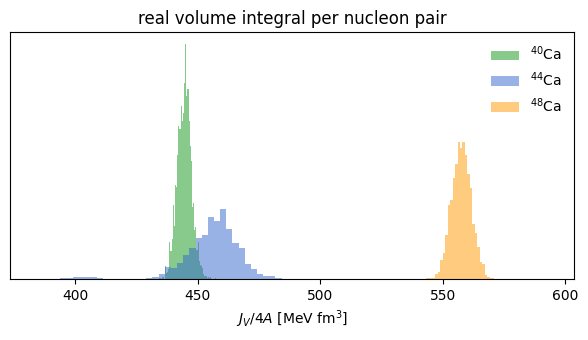

In [16]:
plt.figure(figsize=(6, 3.5))
for key in targets:
    plt.hist(jv_samples[key], bins=50, density=True, color=colors[key], alpha=0.5, label=isotope_label[key])
plt.xlabel(r"$J_V / 4A$ [MeV fm$^3$]")
plt.yticks([])
plt.legend(framealpha=0)
plt.title("real volume integral per nucleon pair")
plt.tight_layout()
plt.show()


## Posterior predictive distributions

Propagating posterior samples through the model gives the spread of *model* curves; adding a draw from the error model on top gives the posterior predictive distribution for the *data*, which is what should be compared to the points.

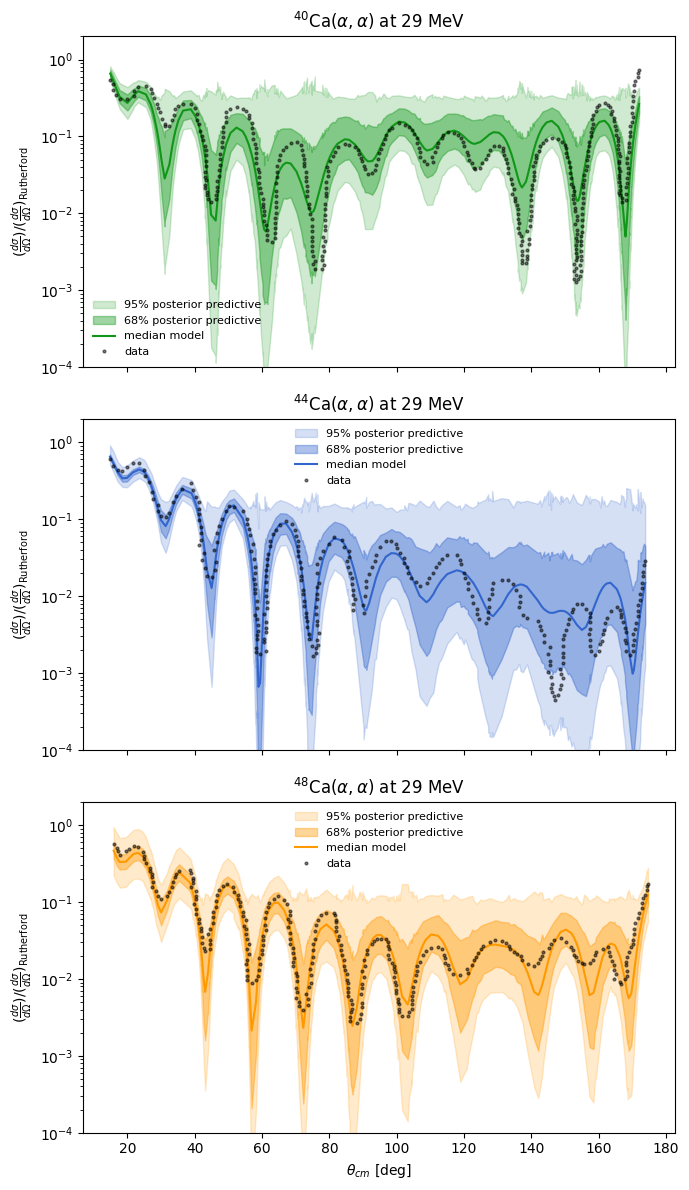

In [17]:
def plot_predictive(ax, key, label=None):
    x = data[key]["x"]
    pred = np.clip(posterior_predictive[key], 1e-6, None)
    lo95, lo68, hi68, hi95 = np.percentile(pred, [2.5, 16, 84, 97.5], axis=0)
    ax.fill_between(x, lo95, hi95, color=colors[key], alpha=0.2, label="95% posterior predictive")
    ax.fill_between(x, lo68, hi68, color=colors[key], alpha=0.4, label="68% posterior predictive")
    ax.plot(x, np.median(posterior_model[key], axis=0), color=colors[key], linewidth=1.5, label="median model")
    ax.plot(x, data[key]["y"], ".", color="k", alpha=0.5, markersize=4, label="data")
    ax.set_yscale("log")
    ax.set_ylim(1e-4, 2)
    ax.set_ylabel(r"$(\frac{d\sigma}{d\Omega}) / (\frac{d\sigma}{d\Omega})_\text{Rutherford}$")
    ax.set_title(label or rf"{isotope_label[key]}($\alpha,\alpha$) at 29 MeV")
    ax.legend(framealpha=0, fontsize=8)


fig, axes = plt.subplots(len(targets), 1, figsize=(7, 4 * len(targets)), sharex=True)
for ax, key in zip(axes, targets):
    plot_predictive(ax, key)
axes[-1].set_xlabel(r"$\theta_{cm}$ [deg]")
plt.tight_layout()
plt.show()

## Empirical coverage

If the error model is right, the central $q$ credible interval of the posterior predictive distribution should contain a fraction $q$ of the data points, for every $q$. Plotting the fraction actually covered against $q$ is a direct check of the calibration of the whole model, potential and error model together.

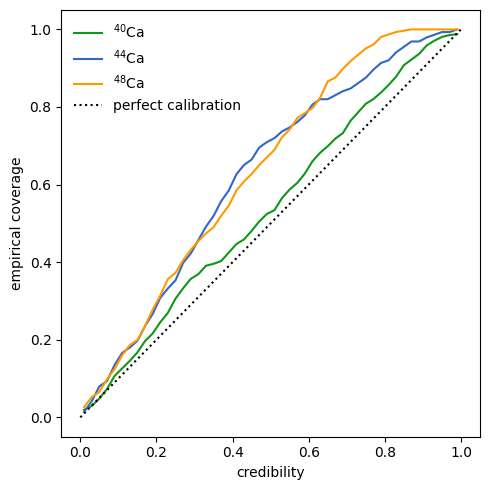

In [18]:
credibility = np.linspace(0.01, 0.99, 50)


def empirical_coverage(pred, y, q):
    lo, hi = np.percentile(pred, [50 * (1 - q), 50 * (1 + q)], axis=0)
    return np.mean((y >= lo) & (y <= hi))


plt.figure(figsize=(5, 5))
for key in targets:
    coverage = [empirical_coverage(posterior_predictive[key], data[key]["y"], q) for q in credibility]
    plt.plot(credibility, coverage, color=colors[key], label=isotope_label[key])
plt.plot([0, 1], [0, 1], "k:", label="perfect calibration")
plt.xlabel("credibility")
plt.ylabel("empirical coverage")
plt.legend(framealpha=0)
plt.tight_layout()
plt.show()


## Summary

- Calibrating a physics model to data means writing down a model for the *residuals* too. With no experimental uncertainties to go on, two learned scales - an absolute floor $s$ and a common relative error $b$ - are the simplest defensible choice, and they cost nothing: the likelihood stays $O(N)$.
- The posterior widths of the potential parameters reflect that choice. Along the $V$-$r_v$ ambiguity they are wide; the volume integral $J_V/4A$ is what the data actually pin down, and it is what to compare between isotopes.
- The error model describes the misfit, it does not fix it: the backward-angle enhancement of $^{40,48}$Ca that Oeschler *et al.* discovered is still there in the residuals, waiting for a better reaction model. The two scales absorb it as best they can - $s$ is three times larger for $^{40}$Ca than for the other two, because the floor is the only way to excuse the misplaced backward-angle minima - and the price shows up in the coverage plot: intervals that are honest on average are too wide where the model is good and too narrow where it is not, so the curves sit above the diagonal at intermediate credibility. A discrepancy that varies with angle is the natural next refinement.

To see where the prior used here came from, and the other families of potentials it excludes, go back to the [mode-exploration notebook](./alpha_ca_mode_exploration.ipynb).
